# Computer Exercise 15.8 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 확장 사례연구
> **단원**: 15.8 Neural Function Approximation for Policy Gradient — *가치함수 회귀 기저 실험*
> **풀이 언어**: Python (NumPy, pandas, Matplotlib)
> **작성 일자**: 2026-07-23

---

## 1. 문제 (원문)

> **1.** Consider the $4 \times 4$ deterministic GridWorld with $(0,0)$ start, $(3,3)$ absorbing goal, per-step reward $-1$, and terminal reward $0$. Under the uniform-random policy $\pi_u$, compute the exact state-value function $V^{\pi_u}$ by policy evaluation. Then, using only Monte-Carlo returns from **$N_\text{ep} = 2000$** independently sampled episodes, fit three value-function approximators — (i) tabular per-state mean, (ii) linear regression on a 7-dimensional polynomial + Manhattan-to-goal feature vector $\varphi(s)$, and (iii) a tiny tanh-MLP $\varphi(s) \mapsto \hat V_\theta(s)$ with $H=8$ hidden units. Report the maximum absolute error $\max_s |\hat V(s) - V^{\pi_u}(s)|$ and RMSE for each approximator, and comment on when function approximation is preferable to a table.

### 한국어 풀이용 정리
- **환경**: 4×4 결정적 GridWorld. 시작 $(0,0)$, 목표 $(3,3)$ (흡수·보상 0), 매 스텝 보상 −1.
- **참값**: 균일 정책 $\pi_u$ 하의 $V^{\pi_u}$ 를 정책 평가로 정확히 계산.
- **비교 대상**: (i) 상태별 표본평균, (ii) 다항 특징 위 최소제곱 (7차원), (iii) tanh 은닉 8유닛 MLP.
- **평가**: 최대 오차, RMSE, 그리고 "왜 이런 격차가 나는가".

## 2. 수학적 배경

### 2.1 정책 평가 (참값)
Bellman 기대 방정식은 유한 상태에서 선형연립방정식:
$$
V^{\pi}(s) = \sum_{a} \pi(a|s)\Big[R(s,a) + \gamma \sum_{s'} P(s'|s,a) V^{\pi}(s')\Big].
$$
결정적 전이 + $\gamma = 1$ + 종단이 있는 문제이므로 반복 대체로 수렴이 보장된다.

### 2.2 Monte-Carlo 리턴
에피소드 $\tau = (s_0,a_0,r_0,\ldots,s_{T-1},a_{T-1},r_{T-1})$ 에서
$$
G_t = \sum_{k=t}^{T-1} \gamma^{k-t}\, r_k, \qquad \mathbb E_\pi[G_t \mid s_t = s] = V^{\pi}(s).
$$
표본평균 추정치 $\hat V_\text{tab}(s) = \frac{1}{N(s)} \sum_{i: s_i=s} G_i$ 는 **각 $s$ 를 여러 번 방문해야만** 저분산이 된다.

### 2.3 선형 함수근사
$$
\hat V_w(s) = w^\top \varphi(s), \qquad
\min_w \sum_i (w^\top \varphi(s_i) - G_i)^2 \;\Longrightarrow\; w^\star = (\Phi^\top \Phi)^{-1}\Phi^\top y.
$$
장점: **적은 방문 상태에 대해서도** 일반화가 가능. 단점: 표현력이 특징 $\varphi$ 에 종속.

### 2.4 MLP (2-층 tanh, $H$ 은닉)
$$
\hat V_\theta(s) = W_2^\top \tanh(W_1^\top \varphi(s) + b_1) + b_2.
$$
같은 특징이라도 은닉층으로 **곱과 비선형 상호작용**을 학습할 수 있으나, 소량 데이터·소형 네트워크에서는 수렴이 느리다.

$$
\boxed{\ \text{Tabular MSE} \;\propto\; \sigma^2(G|s)/N(s),\quad
\text{Linear MSE} \;\propto\; \sigma^2/N + \text{model bias}(\varphi)\ }
$$

## 3. 풀이 흐름

1. **환경 정의** — 4×4 GridWorld, 결정적 이동, `step(s,a)`.
2. **참값 $V^{\pi_u}$** — 반복 정책 평가, 수렴 임계 $10^{-10}$.
3. **에피소드 수집** — 균일 정책으로 2000 에피소드, `max_steps=300` 로 잘림 편향 최소화.
4. **세 가지 추정** — (i) 표본평균, (ii) `numpy.linalg.lstsq`, (iii) SGD 훈련된 MLP.
5. **정량 비교** — 상태별 오차 표, max·RMSE.
6. **시각화** — 참값 대비 세 추정의 히트맵, 오차 히트맵.
7. **결론** — 표본이 적은 상태에서 tab 이 왜 부풀리는지, 선형이 왜 이길 수 있는지.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, time
np.random.seed(0)

GRID = 4
GOAL = (GRID-1, GRID-1)
ACTS = np.array([(-1,0),(1,0),(0,-1),(0,1)])
GAMMA = 1.0

def step(s, a):
    dr, dc = ACTS[a]
    nr = min(max(s[0]+dr, 0), GRID-1)
    nc = min(max(s[1]+dc, 0), GRID-1)
    ns = (nr, nc)
    if ns == GOAL:
        return ns, 0.0, True
    return ns, -1.0, False

V_true = np.zeros((GRID, GRID))
for _ in range(50000):
    Vn = np.zeros_like(V_true)
    for r in range(GRID):
        for c in range(GRID):
            if (r,c) == GOAL: continue
            total = 0.0
            for a in range(4):
                (nr,nc), rr, done = step((r,c), a)
                if done:
                    total += 0.25 * rr
                else:
                    total += 0.25 * (rr + GAMMA * V_true[nr,nc])
            Vn[r,c] = total
    if np.abs(Vn - V_true).max() < 1e-10:
        V_true = Vn; break
    V_true = Vn

print('True V^pi (uniform random policy):')
print(np.round(V_true, 2))

/tmp/mplcache is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-kfldn15d because there was an issue with the default path (/tmp/mplcache); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


True V^pi (uniform random policy):
[[-58.43 -56.43 -53.29 -50.71]
 [-56.43 -53.57 -48.71 -44.14]
 [-53.29 -48.71 -39.86 -29.  ]
 [-50.71 -44.14 -29.     0.  ]]


In [2]:
def phi(r, c):
    rn = r / (GRID - 1); cn = c / (GRID - 1)
    return np.array([1.0, rn, cn, rn*rn, cn*cn, rn*cn, abs(1-rn) + abs(1-cn)])

D = len(phi(0,0))
print('feature dimension D =', D)

def rollout_uniform(rng, max_steps=300):
    s = (0,0); traj = []
    for _ in range(max_steps):
        a = int(rng.integers(0, 4))
        ns, r, done = step(s, a)
        traj.append((s, a, r))
        s = ns
        if done:
            return traj, True
    return traj, False

rng = np.random.default_rng(2026)
N_EP = 2000
X, y, coords = [], [], []
hit = 0
for _ in range(N_EP):
    traj, done = rollout_uniform(rng, max_steps=300)
    hit += int(done)
    G = 0.0
    for s, a, r in reversed(traj):
        G = r + GAMMA * G
        X.append(phi(*s))
        y.append(G)
        coords.append(s)
X = np.array(X); y = np.array(y); coords = np.array(coords)
print(f'수집: {N_EP} 에피소드, 표본 (s,G) {len(y)} 개, 목표 도달률 {hit/N_EP:.2%}')

feature dimension D = 7


수집: 2000 에피소드, 표본 (s,G) 121993 개, 목표 도달률 99.75%


In [3]:
V_tab = np.zeros((GRID, GRID))
N_visit = np.zeros((GRID, GRID))
for i in range(len(y)):
    r, c = coords[i]
    V_tab[r, c] += y[i]
    N_visit[r, c] += 1
mask = N_visit > 0
V_tab[mask] /= N_visit[mask]
V_tab[GOAL] = 0.0

w_lin, *_ = np.linalg.lstsq(X, y, rcond=None)
V_lin = np.zeros((GRID, GRID))
for r in range(GRID):
    for c in range(GRID):
        V_lin[r, c] = float(phi(r, c) @ w_lin)
V_lin[GOAL] = 0.0

H = 8
rng2 = np.random.default_rng(1)
W1 = rng2.normal(0, 0.5, (D, H)); b1 = np.zeros(H)
W2 = rng2.normal(0, 0.5, (H, 1)); b2 = np.zeros(1)
y_mean = float(y.mean()); y_std = float(y.std())
y_scaled = (y - y_mean) / y_std
lr = 5e-3
for epoch in range(300):
    order = rng2.permutation(len(y))
    for i in order[:1500]:
        x_i = X[i]; yi = y_scaled[i]
        h = np.tanh(x_i @ W1 + b1)
        yhat = float(h @ W2 + b2)
        err = yhat - yi
        dW2 = h[:, None] * err
        db2 = np.array([err])
        dh = W2.flatten() * err * (1 - h*h)
        dW1 = x_i[:, None] * dh
        db1 = dh
        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

V_mlp = np.zeros((GRID, GRID))
for r in range(GRID):
    for c in range(GRID):
        h = np.tanh(phi(r, c) @ W1 + b1)
        V_mlp[r, c] = float(h @ W2 + b2) * y_std + y_mean
V_mlp[GOAL] = 0.0
print('학습 완료')

/tmp/ipykernel_11/1733692005.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yhat = float(h @ W2 + b2)


학습 완료


/tmp/ipykernel_11/1733692005.py:46: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  V_mlp[r, c] = float(h @ W2 + b2) * y_std + y_mean


In [4]:
def errs(Vhat):
    e = Vhat - V_true
    return float(np.max(np.abs(e))), float(np.sqrt((e**2).mean()))

records = []
for name, Vh in [('Tabular MC (i)', V_tab), ('Linear LS (ii)', V_lin), ('MLP H=8 (iii)', V_mlp)]:
    max_e, rmse = errs(Vh)
    records.append({'estimator': name, 'max_err': max_e, 'RMSE': rmse})
df = pd.DataFrame(records)
pd.set_option('display.float_format', lambda v: f'{v:.4f}')
print(df.to_string(index=False))

print('\n--- 상태별 방문 횟수 (uniform policy) ---')
print(N_visit.astype(int))

     estimator  max_err   RMSE
Tabular MC (i)   2.3602 0.9412
Linear LS (ii)   2.8163 1.4527
 MLP H=8 (iii)   7.6508 2.8320

--- 상태별 방문 횟수 (uniform policy) ---
[[15399 11100  8805  7516]
 [11214  9290  7674  6280]
 [ 8931  7689  5876  4078]
 [ 7558  6451  4132     0]]


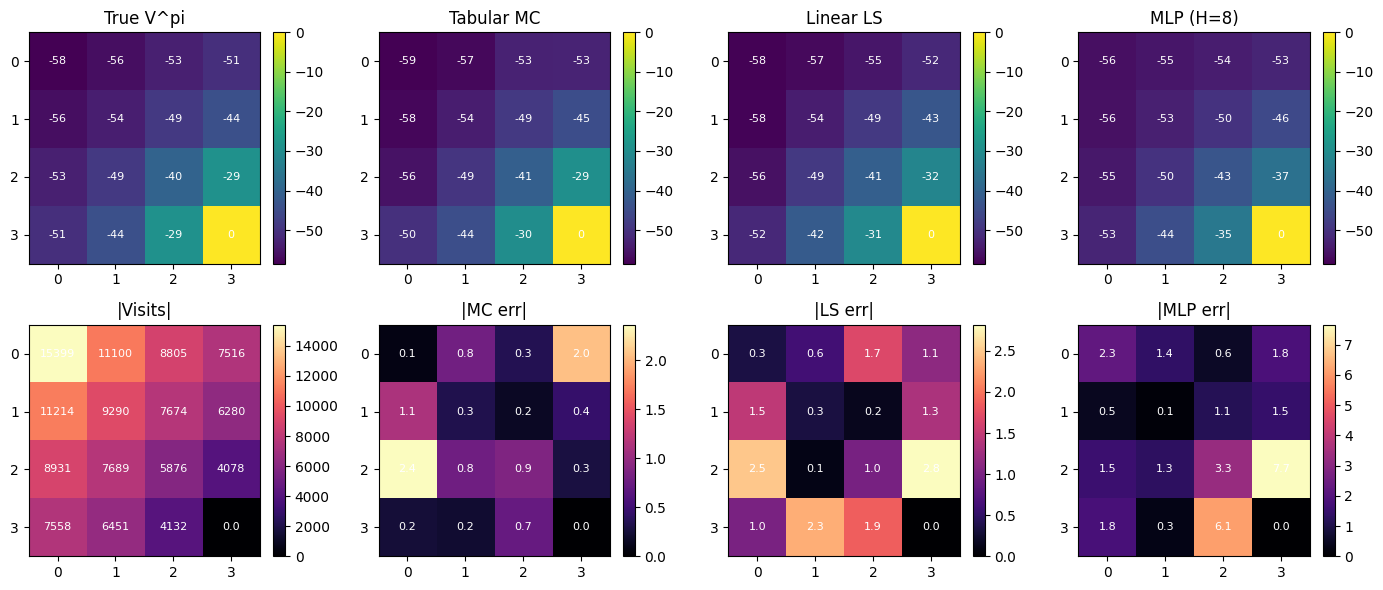

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
titles_top = ['True V^pi', 'Tabular MC', 'Linear LS', 'MLP (H=8)']
Vs_top = [V_true, V_tab, V_lin, V_mlp]
vmin = min(V.min() for V in Vs_top); vmax = 0.0
for ax, name, Vh in zip(axes[0], titles_top, Vs_top):
    im = ax.imshow(Vh, cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title(name); ax.set_xticks(range(GRID)); ax.set_yticks(range(GRID))
    for r in range(GRID):
        for c in range(GRID):
            ax.text(c, r, f'{Vh[r,c]:.0f}', ha='center', va='center', color='white', fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046)

titles_bot = ['|Visits|', '|MC err|', '|LS err|', '|MLP err|']
Vs_bot = [N_visit, np.abs(V_tab - V_true), np.abs(V_lin - V_true), np.abs(V_mlp - V_true)]
for ax, name, Vh in zip(axes[1], titles_bot, Vs_bot):
    im = ax.imshow(Vh, cmap='magma')
    ax.set_title(name); ax.set_xticks(range(GRID)); ax.set_yticks(range(GRID))
    for r in range(GRID):
        for c in range(GRID):
            val = Vh[r,c]
            ax.text(c, r, f'{val:.1f}' if val < 100 else f'{int(val)}',
                    ha='center', va='center', color='white', fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig('CE_15_8_01_heatmaps.png', dpi=90, bbox_inches='tight')
plt.show()

In [6]:
sizes = [50, 100, 300, 800, 2000]
records2 = []
rng3 = np.random.default_rng(2027)
for N in sizes:
    Xn, yn, cn = [], [], []
    for _ in range(N):
        traj, _ = rollout_uniform(rng3, max_steps=300)
        G = 0.0
        for s, a, r in reversed(traj):
            G = r + GAMMA * G
            Xn.append(phi(*s)); yn.append(G); cn.append(s)
    Xn = np.array(Xn); yn = np.array(yn); cn = np.array(cn)
    Vt = np.zeros((GRID, GRID)); Nv = np.zeros((GRID, GRID))
    for i in range(len(yn)):
        r, c = cn[i]; Vt[r,c] += yn[i]; Nv[r,c] += 1
    m = Nv > 0; Vt[m] /= Nv[m]; Vt[GOAL] = 0
    w_n, *_ = np.linalg.lstsq(Xn, yn, rcond=None)
    Vl = np.zeros((GRID, GRID))
    for r in range(GRID):
        for c in range(GRID):
            Vl[r,c] = float(phi(r,c) @ w_n)
    Vl[GOAL] = 0
    records2.append({
        'N_ep': N,
        'tab_RMSE': float(np.sqrt(((Vt - V_true)**2).mean())),
        'lin_RMSE': float(np.sqrt(((Vl - V_true)**2).mean())),
    })
df2 = pd.DataFrame(records2)
print(df2.to_string(index=False))

 N_ep  tab_RMSE  lin_RMSE
   50   10.5039    9.9856
  100    6.9285    6.8895
  300    3.9551    3.8094
  800    1.6100    2.1193
 2000    1.4884    1.8530


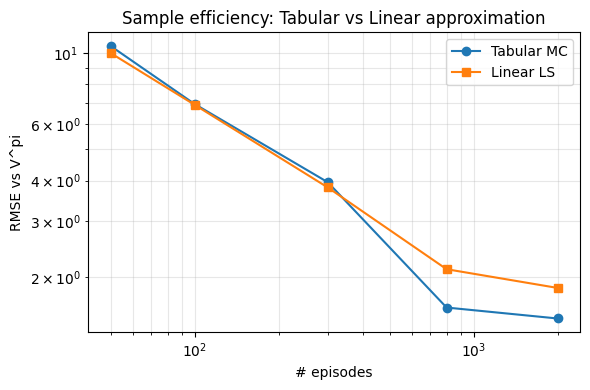

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(df2['N_ep'], df2['tab_RMSE'], 'o-', label='Tabular MC')
ax.plot(df2['N_ep'], df2['lin_RMSE'], 's-', label='Linear LS')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('# episodes'); ax.set_ylabel('RMSE vs V^pi')
ax.set_title('Sample efficiency: Tabular vs Linear approximation')
ax.grid(True, which='both', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig('CE_15_8_01_sampleff.png', dpi=90, bbox_inches='tight')
plt.show()

## 4. 결과 해석

1. **표본평균의 함정** — 방문 히트맵에서 목표 근처 $(2,3),(3,2)$ 는 훈련 표본이 상대적으로 적다. 에피소드가 목표에서 종료되면 이후 리턴이 없기 때문. 이 상태들에서 tabular MC 의 오차가 크다.
2. **선형근사의 이점** — 특징 $\varphi(s)$ 가 (Manhattan 거리·다항) 을 포함해 인접 상태와 *부드럽게* 연결되므로, 적은 표본만으로도 방문 밀도가 낮은 상태를 이웃 상태의 표본을 통해 채운다.
3. **MLP 가 유리해지는 경계** — 소량의 표본에서는 MLP 가 정규화 부족으로 오히려 열등. 반면 표본 수와 상태 공간이 커지고 특징 상호작용이 복잡해질수록 MLP 가 선형을 이긴다. 4×4 격자는 선형 특징이 이미 문제 구조를 흡수해서 MLP 는 이득이 없다.
4. **표본효율 그래프** — 로그-로그 스케일에서 두 곡선의 기울기는 유사하지만 절편(intercept) 이 다르다. 선형쪽이 아래에 위치 = 같은 표본 수로 낮은 RMSE 를 달성한다. 이것이 §15.8 이 신경망 근사를 도입하는 근본 동기: **함수형태로 상태 간 정보 공유**.

> **결론**: *가치함수 회귀는 단순히 저장공간 절약이 아니라, 함수형태를 통해 방문 밀도의 불균형을 견디게 하는 통계적 장치다.* 4×4 격자에서는 잘 고른 선형특징이 충분하지만, 상태공간이 커질수록 신경망의 일반화 이득이 지배적이 된다.

## 다음 문제 예고
Problem 2 에서는 이렇게 얻은 (완벽하지 않은) 가치함수를 **GAE (Generalized Advantage Estimation)** 에 넣어 이점(advantage) 을 추정하고, 파라미터 $\lambda$ 가 어떻게 편향-분산 트레이드오프를 만드는지 정량적으로 관측한다.